# Load data

In [77]:
import shap  # https://github.com/slundberg/shap
import shapreg  # https://github.com/iancovert/shapley-regression
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [112]:
# # Load and split data
# X_train, X_test, Y_train, Y_test = train_test_split(
#     *shap.datasets.adult(), test_size=0.2, random_state=7)
# X_train, X_val, Y_train, Y_val = train_test_split(
#     X_train, Y_train, test_size=0.2, random_state=0)

from ucimlrepo import fetch_ucirepo 
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import callback

  
# fetch dataset 
heart_disease = fetch_ucirepo(id=45) 
  
# data (as pandas dataframes) 
X = heart_disease.data.features 
y = heart_disease.data.targets

mask = X.notna().all(axis=1)

X = X[mask]
y = y[mask]
y = (y > 0).astype(int)
num_classes = y.nunique().item()


X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.2)
X_train, X_val, Y_train, Y_val = train_test_split(X_train, Y_train, test_size=0.1)

# Data scaling
num_features = X_train.shape[1]
feature_names = X_train.columns.tolist()
# ss = StandardScaler()
# ss.fit(X_train.values)
# X_train = ss.transform(X_train.values)
# X_val = ss.transform(X_val.values)
# X_test = ss.transform(X_test.values)
X_train, X_val, X_test = X_train.values, X_val.values, X_test.values

# Train model

In [79]:
import pickle
import os.path
import lightgbm as lgb

In [113]:
model_path = "saved_models/census_model_heart.pkl"

if os.path.isfile(model_path):
    print('Loading saved model')
    with open(model_path, 'rb') as f:
        model = pickle.load(f)

else:
    # Setup
    # params = {
    #     "max_bin": 512,
    #     "learning_rate": 0.05,
    #     "boosting_type": "gbdt",
    #     "objective": "binary",
    #     "metric": "binary_logloss",
    #     "num_leaves": 10,
    #     "verbose": -1,
    #     "min_data": 100,
    #     "boost_from_average": True
    # }
    params = {
        "max_bin": 512,
        "learning_rate": 0.05,
        "boosting_type": "gbdt",
        "objective": "multiclass",
        "metric": "multi_logloss",
        "num_classes": num_classes,
        "num_leaves": 20,
        "verbose": -1,
        "min_data": 100,
        "boost_from_average": True
    }

    # More setup
    d_train = lgb.Dataset(X_train, label=Y_train)
    d_val = lgb.Dataset(X_val, label=Y_val)

    # Train model
    model = lgb.train(params, d_train, 10000, valid_sets=[d_val])
    
    # Save model
    with open(model_path, 'wb') as f:
        pickle.dump(model, f)

In [114]:
model.predict(X_train).shape

(213, 2)

# Train surrogate

In [115]:
import torch
import torch.nn as nn
from fastshap.utils import MaskLayer1d
from fastshap import Surrogate, KLDivLoss

In [116]:
# Select device
device = torch.device('cuda')

In [117]:
def build_surrogate(
    surrogate_path: str,
    produce_surr_model: callable,
    num_features,
    device: torch.device,
    X_train = None,
    X_val = None,
    overwrite: bool = False
):
    surrogate_model = produce_surr_model().to(device)

    if os.path.isfile(surrogate_path) and not overwrite:
        print('Loading saved surrogate model')
        state = torch.load(surrogate_path)
        surrogate_model.load_state_dict(state)
        surrogate = Surrogate(surrogate_model, num_features)
    else:
        surrogate = Surrogate(surrogate_model, num_features)
        print(surrogate)

        # Set up original model
        def original_model(x):
            pred = model.predict(x.cpu().numpy())
            if pred.shape[-1] == 1:
                pred = np.stack([1 - pred, pred]).T
            return torch.tensor(pred, dtype=torch.float32, device=x.device)

        # Train
        surrogate.train_original_model(
            X_train,
            X_val,
            original_model,
            batch_size=64,
            max_epochs=1000,
            loss_fn=KLDivLoss(),
            validation_samples=10,
            validation_batch_size=10000,
            verbose=True,
            lookback=200
            )
        surrogate_model.to("cpu")
        torch.save(surrogate_model.state_dict(), surrogate_path)
        surrogate_model.to(device)
    return surrogate

In [118]:
# Check for model
def produce_surr_model():
    return nn.Sequential(
        MaskLayer1d(value=0, append=True),
        nn.Linear(2 * num_features, 128),
        nn.ELU(inplace=True),
        nn.Linear(128, 128),
        nn.ELU(inplace=True),
        nn.Linear(128, num_classes))

surrogate_path = "saved_models/census_surrogate.pt"

surrogate = build_surrogate(surrogate_path, produce_surr_model, num_features, device, X_train, X_val, True)

torch.Size([240, 13]) torch.Size([240, 2]) torch.Size([240, 13])
----- Epoch = 1 -----
Val loss = 0.8484

New best epoch, loss = 0.8484

----- Epoch = 2 -----
Val loss = 0.4609

New best epoch, loss = 0.4609

----- Epoch = 3 -----
Val loss = 0.3418

New best epoch, loss = 0.3418

----- Epoch = 4 -----
Val loss = 0.2708

New best epoch, loss = 0.2708

----- Epoch = 5 -----
Val loss = 0.2134

New best epoch, loss = 0.2134

----- Epoch = 6 -----
Val loss = 0.2801

----- Epoch = 7 -----
Val loss = 0.2236

----- Epoch = 8 -----
Val loss = 0.1960

New best epoch, loss = 0.1960

----- Epoch = 9 -----
Val loss = 0.2201

----- Epoch = 10 -----
Val loss = 0.2419

----- Epoch = 11 -----
Val loss = 0.2298

----- Epoch = 12 -----
Val loss = 0.2007

----- Epoch = 13 -----
Val loss = 0.1947

New best epoch, loss = 0.1947

----- Epoch = 14 -----
Val loss = 0.2023

----- Epoch = 15 -----
Val loss = 0.2461

----- Epoch = 16 -----
Val loss = 0.2035

----- Epoch = 17 -----
Val loss = 0.3006

----- Epoch =

# Train FastSHAP

In [119]:
from fastshap import FastSHAP

In [120]:

# Check for model

def produce_expl_model():
    return nn.Sequential(
        nn.Linear(num_features, 128),
        nn.ReLU(inplace=True),
        nn.Linear(128, 128),
        nn.ReLU(inplace=True),
        nn.Linear(128, num_classes * num_features))

def build_explainer(
    explainer_path,
    produce_expl_model,
    surrogate,
    num_features,
    device: torch.device,
    X_train = None,
    X_val = None,
    overwrite: bool = False
):
    # Create explainer model
    explainer = produce_expl_model().to(device)

    if os.path.isfile(explainer_path) and not overwrite:
        print('Loading saved explainer model')
        state = torch.load(explainer_path)

        explainer.load_state_dict(state)

        fastshap = FastSHAP(explainer, surrogate, normalization='additive',
                            link=nn.Softmax(dim=-1))

    else:

        # Set up FastSHAP object
        fastshap = FastSHAP(explainer, surrogate, normalization='additive',
                            link=nn.Softmax(dim=-1))

        # Train
        fastshap.train(
            X_train,
            X_val[:100],
            batch_size=32,
            num_samples=32,
            max_epochs=200,
            validation_samples=128,
            verbose=True,
            lookback=30)
        
        # Save explainer
        explainer.cpu()
        torch.save(explainer.state_dict(), explainer_path)
        explainer.to(device)
    return explainer, fastshap

In [121]:
explainer_path = "saved_models/census_explainer.pt"
explainer, fastshap = build_explainer(explainer_path, produce_expl_model, surrogate, num_features, device, X_train, X_val, True)

----- Epoch = 1 -----
Val loss = 372.804497

New best epoch, loss = 372.804497

----- Epoch = 2 -----
Val loss = 116.007807

New best epoch, loss = 116.007807

----- Epoch = 3 -----
Val loss = 47.129178

New best epoch, loss = 47.129178

----- Epoch = 4 -----
Val loss = 33.871305

New best epoch, loss = 33.871305

----- Epoch = 5 -----
Val loss = 32.160447

New best epoch, loss = 32.160447

----- Epoch = 6 -----
Val loss = 26.142376

New best epoch, loss = 26.142376

----- Epoch = 7 -----
Val loss = 18.698873

New best epoch, loss = 18.698873

----- Epoch = 8 -----
Val loss = 14.940813

New best epoch, loss = 14.940813

----- Epoch = 9 -----
Val loss = 12.995787

New best epoch, loss = 12.995787

----- Epoch = 10 -----
Val loss = 11.852170

New best epoch, loss = 11.852170

----- Epoch = 11 -----
Val loss = 10.882009

New best epoch, loss = 10.882009

----- Epoch = 12 -----
Val loss = 10.144288

New best epoch, loss = 10.144288

----- Epoch = 13 -----
Val loss = 9.222704

New best epoc

# Compare with KernelSHAP

In [122]:
import matplotlib.pyplot as plt

In [123]:
# Setup for KernelSHAP
def imputer(x, S):
    x = torch.tensor(x, dtype=torch.float32, device=device)
    S = torch.tensor(S, dtype=torch.float32, device=device)
    pred = surrogate(x, S).softmax(dim=-1)
    return pred.cpu().data.numpy()

In [124]:
# Select example
idx = 0 #np.random.choice(len(X_test))
print(idx)
x = X_test[idx:idx+1]
y = int(Y_test.values.flatten()[idx])
print(f"Correct label y = {y}")

# Run FastSHAP
fastshap_values = fastshap.shap_values(x)[0]

# Run KernelSHAP to convergence
game = shapreg.games.PredictionGame(imputer, x)
shap_values, all_results = shapreg.shapley.ShapleyRegression(
    game, batch_size=32, paired_sampling=False, detect_convergence=True,
    bar=True, return_all=True)

0
Correct label y = 1


  0%|          | 0/1 [00:00<?, ?it/s]

In [125]:
shap_values.values.shape

(13, 2)

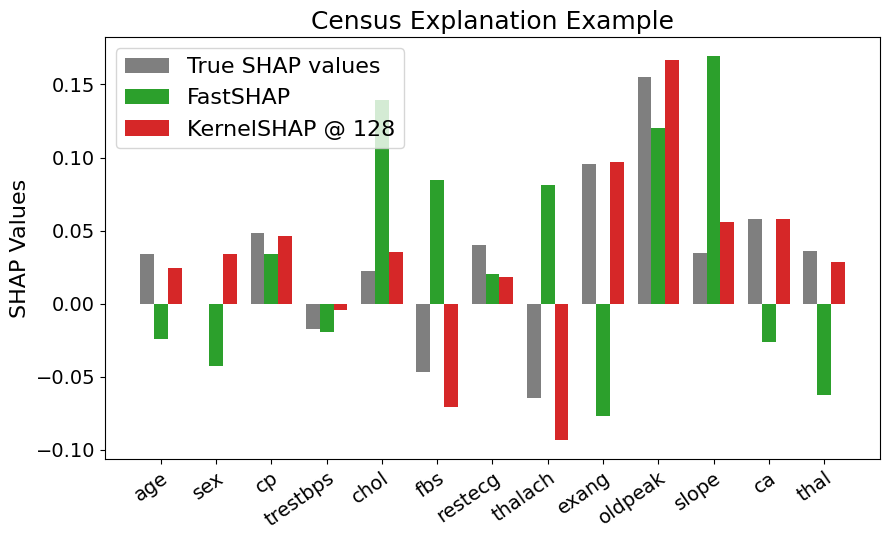

In [126]:
# Create figure
plt.figure(figsize=(9, 5.5))

# Bar chart
width = 0.75
kernelshap_iters = 128
plt.bar(np.arange(num_features) - width / 3, shap_values.values[:, y],
        width / 3, label='True SHAP values', color='tab:gray')
plt.bar(np.arange(num_features), fastshap_values[:, y],
        width / 3, label='FastSHAP', color='tab:green')
plt.bar(np.arange(num_features) + width / 3,
        all_results['values'][list(all_results['iters']).index(kernelshap_iters)][:, y],
        width / 3, label='KernelSHAP @ {}'.format(kernelshap_iters), color='tab:red')

# Annotations
plt.legend(fontsize=16)
plt.tick_params(labelsize=14)
plt.ylabel('SHAP Values', fontsize=16)
plt.title('Census Explanation Example', fontsize=18)
plt.xticks(np.arange(num_features), feature_names,
           rotation=35, rotation_mode='anchor', ha='right')

plt.tight_layout()
plt.show()